## 1. Imports and Setup

This section imports all the necessary libraries for data preprocessing, model building, evaluation, and ensemble learning. Ensemble methods like RandomForest, GradientBoosting, Voting, and Stacking are included because they often improve performance by combining predictions from multiple classifiers.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## 2. Data Loading and Cleaning

Here we load the Adult Income dataset and clean it. Missing values indicated by '?' are replaced with 'Unknown'. String columns are stripped of spaces, and columns `fnlwgt` and `education` are dropped because they are not useful for prediction.

In [4]:

def load_and_basic_clean(train_path="data/adult.data", test_path="data/adult.test"):
    column_names = [
        "age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"
    ]
    df_train = pd.read_csv(train_path, names=column_names)
    df_test  = pd.read_csv(test_path, skiprows=1, names=column_names)

    for col in ["workclass", "occupation", "native-country"]:
        df_train[col] = df_train[col].replace("?", "Unknown")
        df_test[col]  = df_test[col].replace("?", "Unknown")

    for df in (df_train, df_test):
        obj_cols = df.select_dtypes(include="object").columns
        for c in obj_cols:
            df[c] = df[c].str.strip()

    df_train["income"] = df_train["income"].str.replace(".", "", regex=False)
    df_test["income"]  = df_test["income"].str.replace(".", "", regex=False)

    df_train = df_train.drop(columns=["fnlwgt", "education"]) 
    df_test  = df_test.drop(columns=["fnlwgt", "education"]) 

    return df_train, df_test

df_train, df_test = load_and_basic_clean()
df_train.head(2)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


## 3. Define Target and Features

The target variable is binary: 1 if income >50K, 0 otherwise. We separate the features and target for both training and holdout sets and check the positive class distribution.

In [5]:

TARGET = "income"
X = df_train.drop(columns=[TARGET])
y = (df_train[TARGET] == ">50K").astype(int)

X_holdout = df_test.drop(columns=[TARGET])
y_holdout = (df_test[TARGET] == ">50K").astype(int)

print("Positive rate in train:", y.mean().round(3), " | Positive rate in holdout:", y_holdout.mean().round(3))


Positive rate in train: 0.241  | Positive rate in holdout: 0.236


## 4. Preprocessing Pipelines

Numeric features are split into skewed and non-skewed. Skewed numeric columns are log-transformed to reduce skewness. Categorical columns are imputed with the most frequent value and one-hot encoded.

In [6]:

numeric_cols_all = X.select_dtypes(include=[np.number]).columns.tolist()
skewed_numeric = [c for c in ["capital-gain", "capital-loss"] if c in numeric_cols_all]
base_numeric   = [c for c in numeric_cols_all if c not in skewed_numeric]
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numeric_base = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
numeric_skewed = make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler())
categorical = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))

preprocess = ColumnTransformer([
    ("num_base", numeric_base, base_numeric),
    ("num_skewed", numeric_skewed, skewed_numeric),
    ("cat", categorical, categorical_cols),
], remainder="drop", verbose_feature_names_out=False)


## 5. Define Base and Ensemble Models

Tree-based and boosting methods usually perform well on tabular data. Voting and stacking ensembles are included to combine strengths of multiple models.

In [7]:

logreg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)
svc = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

voting = VotingClassifier(estimators=[('lr', logreg), ('rf', rf), ('gb', gb)], voting='soft')
stacking = StackingClassifier(estimators=[('lr', logreg), ('rf', rf), ('gb', gb), ('svc', svc)], final_estimator=LogisticRegression(max_iter=1000))

models = {
    "RandomForest": rf,
    "GradientBoosting": gb,
    "AdaBoost": ada,
    "VotingEnsemble": voting,
    "StackingEnsemble": stacking
}


## 6. Build Pipelines and Hyperparameter Grids

Hyperparameter grids are defined for models that support tuning. Voting and stacking ensembles are not tuned directly.

In [8]:

pipelines = {name: Pipeline([('preprocess', preprocess), ('clf', model)]) for name, model in models.items()}

param_grids = {
    "RandomForest": {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10, None], 'clf__min_samples_split': [2, 5]},
    "GradientBoosting": {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1, 0.2], 'clf__max_depth': [3, 5]},
    "AdaBoost": {'clf__n_estimators': [50, 100, 200], 'clf__learning_rate': [0.5, 1.0]},
    "VotingEnsemble": {},
    "StackingEnsemble": {}
}


## 7. Model Training and Hyperparameter Tuning

5-fold stratified cross-validation ensures class balance. Each model is tuned using ROC-AUC.

In [9]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_estimators = {}
for name, model in pipelines.items():
    print(f"Running model: {name}...")
    if param_grids[name]:
        gs = GridSearchCV(model, param_grids[name], scoring='roc_auc', cv=cv, n_jobs=-1)
        gs.fit(X, y)
        best_estimators[name] = gs.best_estimator_
        print(f"Best params for {name}: {gs.best_params_} | Best ROC-AUC: {gs.best_score_:.3f}\n")
    else:
        model.fit(X, y)
        best_estimators[name] = model


Running model: RandomForest...
Best params for RandomForest: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200} | Best ROC-AUC: 0.916

Running model: GradientBoosting...
Best params for GradientBoosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200} | Best ROC-AUC: 0.929

Running model: AdaBoost...


/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.

Best params for AdaBoost: {'clf__learning_rate': 1.0, 'clf__n_estimators': 200} | Best ROC-AUC: 0.924

Running model: VotingEnsemble...
Running model: StackingEnsemble...


## 8. Evaluate and Select Best Ensemble

Select the model with highest ROC-AUC on the training set, fit it on full training data, and evaluate on holdout set using ROC-AUC, PR-AUC, classification report, and confusion matrix.

Selected final ensemble model: VotingEnsemble
Holdout ROC-AUC: 0.915
Holdout PR-AUC: 0.797

Classification report:
               precision    recall  f1-score   support

           0      0.888     0.940     0.913     12435
           1      0.760     0.615     0.680      3846

    accuracy                          0.863     16281
   macro avg      0.824     0.778     0.797     16281
weighted avg      0.858     0.863     0.858     16281



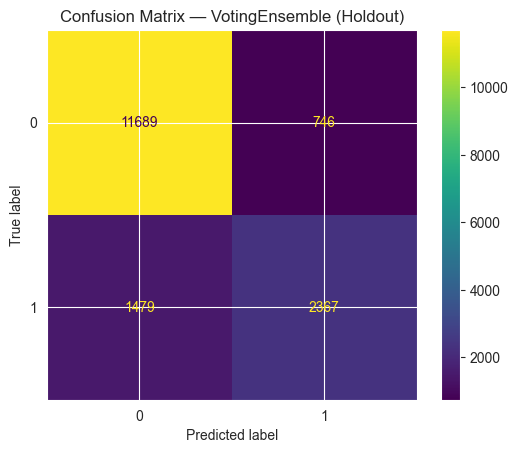

In [10]:

best_name = max(best_estimators, key=lambda n: roc_auc_score(y, best_estimators[n].predict_proba(X)[:,1]))
best_model = best_estimators[best_name]

print("Selected final ensemble model:", best_name)

best_model.fit(X, y)
y_prob = best_model.predict_proba(X_holdout)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Holdout ROC-AUC:", roc_auc_score(y_holdout, y_prob).round(3))
print("Holdout PR-AUC:", average_precision_score(y_holdout, y_prob).round(3))
print("\nClassification report:\n", classification_report(y_holdout, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_holdout, y_pred)
plt.title(f"Confusion Matrix — {best_name} (Holdout)")
plt.show()
